<a href="https://colab.research.google.com/github/aszczi/Urban_mobility_in_Cracow/blob/main/Mobilnosc_miejska_w_Krakowie_JOIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wgranie pliku z juz zebranymi danymi

In [24]:
import os
import requests
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files
from google.colab import output
output.enable_custom_widget_manager()

GITHUB_CSV_URL = "https://raw.githubusercontent.com/aszczi/Urban_mobility_in_Cracow/refs/heads/main/traffic_history.csv"
CSV_FILE = "traffic_history.csv"
data_ready = False

status_out = widgets.Output()
github_btn = widgets.Button(description="Pobierz z GitHub", button_style='info', icon='download')
upload_btn = widgets.Button(description="Wgraj z dysku", button_style='info', icon='upload')
ok_btn = widgets.Button(description="Zatwierdź (OK)", button_style='success', disabled=True, icon='check')

def mark_ready():
    global data_ready
    data_ready = True
    ok_btn.disabled = False
    with status_out:
        print("Dane są gotowe do zatwierdzenia.")

def on_github_clicked(_):
    with status_out:
        clear_output()
        print("Pobieranie z GitHub...")
        try:
            res = requests.get(GITHUB_CSV_URL, timeout=20)
            res.raise_for_status()
            with open(CSV_FILE, 'wb') as f: f.write(res.content)
            print(f"Pobrano: {CSV_FILE} ({os.path.getsize(CSV_FILE)} bajtów)")
            mark_ready()
        except Exception as e:
            print(f"Błąd pobierania: {e}")

def on_upload_clicked(_):
    with status_out:
        clear_output()
        print("Oczekiwanie na wybór pliku...")
        uploaded = files.upload()
        if uploaded:
            fname = list(uploaded.keys())[0]
            with open(CSV_FILE, "wb") as f: f.write(uploaded[fname])
            print(f"Wgrano: {fname} i zapisano jako {CSV_FILE}")
            mark_ready()
        else:
            print("Nie wybrano pliku.")

def on_ok_clicked(_):
    github_btn.disabled = True
    upload_btn.disabled = True
    ok_btn.disabled = True
    with status_out:
        clear_output()
        print("Dane zatwierdzone. Możesz przejść do kolejnych komórek.")

github_btn.on_click(on_github_clicked)
upload_btn.on_click(on_upload_clicked)
ok_btn.on_click(on_ok_clicked)

print("KONFIGURACJA DANYCH")
display(widgets.HBox([github_btn, upload_btn]))
display(ok_btn)
display(status_out)

KONFIGURACJA DANYCH


Button(button_style='success', description='Zatwierdź (OK)', disabled=True, icon='check', style=ButtonStyle())

Output()

In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output

check_out = widgets.Output()
check_btn = widgets.Button(description="Sprawdź i Odblokuj", button_style='warning')

def on_check_clicked(_):
    with check_out:
        clear_output()
        if data_ready:
            print("Dane gotowe. Możesz teraz uruchomić kolejne komórki.")
            check_btn.button_style = 'success'
        else:
            print("Najpierw wybierz źródło i kliknij 'Zatwierdź (OK)' w pierwszej komórce!")

check_btn.on_click(on_check_clicked)
display(check_btn, check_out)

if not data_ready:
    raise RuntimeError("ZATRZYMANO: Dane nie zostały jeszcze zatwierdzone w pierwszej komórce. Kliknij OK powyżej i spróbuj ponownie.")
else:
    print("Weryfikacja pozytywna. Kontynuacja...")

Button(button_style='warning', description='Sprawdź i Odblokuj', style=ButtonStyle())

Output()

Weryfikacja pozytywna. Kontynuacja...


In [32]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
from google.colab import userdata
import time
import os

TOMTOM_API_KEY = userdata.get('TOMTOM_API_KEY')

if not TOMTOM_API_KEY:
    raise ValueError(
        "Nie udało się pobrać klucza TOMTOM_API_KEY"
    )

CSV_FILE = "traffic_history.csv"


POINTS = [
    {
        "name": "Rondo Mogilskie",
        "lat": 50.0672,
        "lon": 19.9595
    },
    {
        "name": "Lubomirskiego",
        "lat": 50.0676,
        "lon": 19.9536
    },
    {
        "name": "Aleja Powstania Warszawskiego",
        "lat": 50.0647,
        "lon": 19.9608
    },
    {
        "name": "Grzegórzecka",
        "lat": 50.0578,
        "lon": 19.9564
    },
    {
        "name": "Rondo Grzegórzeckie",
        "lat": 50.0576,
        "lon": 19.9609
    },
    {
        "name": "Galeria Krakowska / Pawia",
        "lat": 50.0669,
        "lon": 19.9457
    },
    {
        "name": "Dworzec Główny Tunel",
        "lat": 50.0686,
        "lon": 19.9477
    },
    {
        "name": "Aleje Trzech Wieszczów - AGH",
        "lat": 50.0674,
        "lon": 19.9209
    },
    {
        "name": "Plac Inwalidów",
        "lat": 50.0671,
        "lon": 19.9269
    },
    {
        "name": "Nowy Kleparz",
        "lat": 50.0731,
        "lon": 19.9352
    },
    {
        "name": "Aleja Słowackiego / Łobzowska",
        "lat": 50.0692,
        "lon": 19.9302
    },
    {
        "name": "Cracovia / Aleja Mickiewicza",
        "lat": 50.0595,
        "lon": 19.9235
    },
    {
        "name": "Rondo Grunwaldzkie",
        "lat": 50.0492,
        "lon": 19.9317
    },
    {
        "name": "Most Dębnicki",
        "lat": 50.0530,
        "lon": 19.9278
    },
    {
        "name": "Rondo Matecznego",
        "lat": 50.0364,
        "lon": 19.9406
    },
    {
        "name": "Kalwaryjska",
        "lat": 50.0412,
        "lon": 19.9443
    },
    {
        "name": "Bonarka / Kamieńskiego",
        "lat": 50.0298,
        "lon": 19.9513
    },
    {
        "name": "Zakopiańska / Brożka",
        "lat": 50.0227,
        "lon": 19.9349
    },
    {
        "name": "Łagiewniki",
        "lat": 50.0202,
        "lon": 19.9378
    },
    {
        "name": "Opolska Estakada",
        "lat": 50.0857,
        "lon": 19.9536
    },
    {
        "name": "Rondo Polsadu",
        "lat": 50.0879,
        "lon": 19.9618
    },
    {
        "name": "Rondo Barei",
        "lat": 50.0911,
        "lon": 19.9742
    },
    {
        "name": "Aleja 29 Listopada / Opolska",
        "lat": 50.0861,
        "lon": 19.9520
    },
    {
        "name": "Aleja 29 Listopada / Dobrego Pasterza",
        "lat": 50.0953,
        "lon": 19.9746
    },
    {
        "name": "Rondo Ofiar Katynia",
        "lat": 50.0879,
        "lon": 19.8976
    },
    {
        "name": "Bronowice SKA",
        "lat": 50.0814,
        "lon": 19.8994
    },
    {
        "name": "Armii Krajowej / Zarzecze",
        "lat": 50.0738,
        "lon": 19.8985
    },
    {
        "name": "Czarnowiejska / Armii Krajowej",
        "lat": 50.0690,
        "lon": 19.9075
    },
    {
        "name": "Rondo Czyżyńskie",
        "lat": 50.0729,
        "lon": 20.0167
    },
    {
        "name": "Plac Centralny",
        "lat": 50.0720,
        "lon": 20.0372
    },
    {
        "name": "Aleja Pokoju / Centralna",
        "lat": 50.0667,
        "lon": 20.0028
    },
    {
        "name": "Nowohucka / Klimeckiego",
        "lat": 50.0503,
        "lon": 19.9765
    },
    {
        "name": "M1 / Aleja Pokoju",
        "lat": 50.0661,
        "lon": 20.0149
    },
    {
        "name": "Wielicka / Powstańców Wielkopolskich",
        "lat": 50.0335,
        "lon": 19.9621
    },
    {
        "name": "Estakada Obrońców Lwowa",
        "lat": 50.0396,
        "lon": 19.9627
    },
    {
        "name": "Bieżanowska / Wielicka",
        "lat": 50.0207,
        "lon": 19.9820
    },
    {
        "name": "Prokocim Szpital",
        "lat": 50.0117,
        "lon": 20.0005
    },
    {
        "name": "Węzeł Łagiewniki",
        "lat": 50.0136,
        "lon": 19.9325
    },
    {
        "name": "Węzeł Balice / A4",
        "lat": 50.0878,
        "lon": 19.7937
    },
    {
        "name": "Węzeł Tyniec / A4",
        "lat": 50.0196,
        "lon": 19.8078
    },
    {
        "name": "Węzeł Wielicka / A4",
        "lat": 50.0034,
        "lon": 20.0065
    }
]


def fetch_tomtom_flow(api_key, lat, lon):
    api_key = api_key.strip()

    if not api_key:
        raise ValueError("Brak klucza TOMTOM_API_KEY.")

    url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/18/json"

    params = {
        "key": api_key,
        "point": f"{lat},{lon}",
        "unit": "kmph",
        "openLr": "false"
    }

    response = requests.get(url, params=params, timeout=15)

    if not response.ok:
        raise RuntimeError(
            f"TomTom HTTP {response.status_code}: {response.text[:300]}"
        )

    data = response.json()
    flow = data.get("flowSegmentData")

    if not flow:
        raise RuntimeError(f"Brak pola flowSegmentData w odpowiedzi: {data}")

    return flow


def collect_once():
    rows = []
    now = datetime.now()

    for point in POINTS:
        try:
            flow = fetch_tomtom_flow(
                TOMTOM_API_KEY,
                point["lat"],
                point["lon"]
            )

            current_speed = flow.get("currentSpeed")
            free_flow_speed = flow.get("freeFlowSpeed")
            current_travel_time = flow.get("currentTravelTime")
            free_flow_travel_time = flow.get("freeFlowTravelTime")
            confidence = flow.get("confidence")
            road_closure = flow.get("roadClosure")

            if current_travel_time is not None and free_flow_travel_time is not None:
                delay_sec = max(0, current_travel_time - free_flow_travel_time)
            else:
                delay_sec = None

            if current_speed is not None and free_flow_speed not in [None, 0]:
                speed_ratio = current_speed / free_flow_speed
                congestion_index = round((1 - speed_ratio) * 100, 2)
                congestion_index = max(0, congestion_index)
            else:
                speed_ratio = None
                congestion_index = None

            rows.append({
                "timestamp": now,
                "point_name": point["name"],
                "lat": point["lat"],
                "lon": point["lon"],
                "current_speed_kmph": current_speed,
                "free_flow_speed_kmph": free_flow_speed,
                "current_travel_time_sec": current_travel_time,
                "free_flow_travel_time_sec": free_flow_travel_time,
                "delay_sec": delay_sec,
                "speed_ratio": speed_ratio,
                "congestion_index_pct": congestion_index,
                "confidence": confidence,
                "road_closure": road_closure
            })

            print(
                f"{point['name']}: "
                f"{current_speed} km/h, "
                f"opóźnienie {delay_sec} s, "
                f"indeks korka {congestion_index}%"
            )

        except Exception as e:
            print(f"Błąd dla punktu {point['name']}: {e}")

    return pd.DataFrame(rows)


def save_to_csv(df):
    file_exists = os.path.exists(CSV_FILE)

    df.to_csv(
        CSV_FILE,
        mode="a",
        header=not file_exists,
        index=False,
        encoding="utf-8"
    )

    print(f"Zapisano {len(df)} rekordów do {CSV_FILE}")


def collect_loop(interval_minutes=5, number_of_rounds=12):
    for i in range(number_of_rounds):
        print(f"\nPomiar {i + 1}/{number_of_rounds}")
        df = collect_once()

        if not df.empty:
            save_to_csv(df)

        if i < number_of_rounds - 1:
            time.sleep(interval_minutes * 60)


def load_history():
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"Nie ma pliku {CSV_FILE}. Najpierw uruchom collect_once() albo collect_loop()."
        )

    df = pd.read_csv(CSV_FILE)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    df["date"] = df["timestamp"].dt.date

    return df


def show_summary(top_n=None):
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            liczba_pomiarow=("timestamp", "count"),
            srednia_predkosc_kmh=("current_speed_kmph", "mean"),
            min_predkosc_kmh=("current_speed_kmph", "min"),
            max_predkosc_kmh=("current_speed_kmph", "max"),
            srednie_opoznienie_sec=("delay_sec", "mean"),
            max_opoznienie_sec=("delay_sec", "max"),
            sredni_indeks_korka_pct=("congestion_index_pct", "mean")
        )
        .round(2)
        .reset_index()
        .sort_values("srednie_opoznienie_sec", ascending=False)
    )

    if top_n:
        summary = summary.head(top_n)

    print(summary.to_string(index=False))


def show_average_speed_summary(top_n=30):
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            srednia_predkosc_kmh=("current_speed_kmph", "mean"),
            minimalna_predkosc_kmh=("current_speed_kmph", "min"),
            maksymalna_predkosc_kmh=("current_speed_kmph", "max"),
            srednie_opoznienie_sec=("delay_sec", "mean"),
            liczba_pomiarow=("timestamp", "count")
        )
        .round(2)
        .reset_index()
        .sort_values("srednia_predkosc_kmh", ascending=True)
        .head(top_n)
    )

    print(summary.to_string(index=False))


def plot_current_congestion_ranking(top_n=20):
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            avg_delay_sec=("delay_sec", "mean"),
            max_delay_sec=("delay_sec", "max"),
            avg_speed=("current_speed_kmph", "mean"),
            avg_congestion=("congestion_index_pct", "mean"),
            measurements=("timestamp", "count")
        )
        .reset_index()
        .sort_values("avg_delay_sec", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(summary["point_name"], summary["avg_delay_sec"])

    plt.gca().invert_yaxis()
    plt.title(f"TOP {top_n} najbardziej zakorkowanych punktów")
    plt.xlabel("Średnie opóźnienie [s]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_speed_ranking(top_n=20):
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            avg_speed=("current_speed_kmph", "mean"),
            avg_delay_sec=("delay_sec", "mean"),
            avg_congestion=("congestion_index_pct", "mean"),
            measurements=("timestamp", "count")
        )
        .reset_index()
        .sort_values("avg_speed", ascending=True)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(summary["point_name"], summary["avg_speed"])

    plt.gca().invert_yaxis()
    plt.title(f"TOP {top_n} punktów z najniższą średnią prędkością")
    plt.xlabel("Średnia prędkość [km/h]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_average_speed_by_point(top_n=25):
    df = load_history()

    summary = (
        df.groupby("point_name")["current_speed_kmph"]
        .mean()
        .sort_values(ascending=True)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(summary.index, summary.values)

    plt.gca().invert_yaxis()
    plt.title(f"Średnia prędkość — TOP {top_n} najwolniejszych lokalizacji")
    plt.xlabel("Średnia prędkość [km/h]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_latest_snapshot(top_n=20):
    df = load_history()

    latest_time = df["timestamp"].max()
    latest = df[df["timestamp"] == latest_time].copy()

    latest = latest.sort_values("delay_sec", ascending=False).head(top_n)

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(latest["point_name"], latest["delay_sec"])

    plt.gca().invert_yaxis()
    plt.title(f"Najnowszy pomiar korków — {latest_time}")
    plt.xlabel("Opóźnienie [s]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_latest_speed_snapshot(top_n=20):
    df = load_history()

    latest_time = df["timestamp"].max()
    latest = df[df["timestamp"] == latest_time].copy()

    latest = latest.sort_values("current_speed_kmph", ascending=True).head(top_n)

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(latest["point_name"], latest["current_speed_kmph"])

    plt.gca().invert_yaxis()
    plt.title(f"Najnowszy pomiar prędkości — {latest_time}")
    plt.xlabel("Prędkość [km/h]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_delay_by_hour_top(top_n=8):
    df = load_history()

    top_points = (
        df.groupby("point_name")["delay_sec"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    hourly = (
        filtered.groupby(["hour", "point_name"])["delay_sec"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 7))

    for point_name in top_points:
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["delay_sec"],
            marker="o",
            linewidth=2,
            label=point_name
        )

    plt.title(f"Średnie opóźnienie według godziny — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Średnie opóźnienie [s]")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Lokalizacja",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()


def plot_congestion_by_hour_top(top_n=8):
    df = load_history()

    top_points = (
        df.groupby("point_name")["congestion_index_pct"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    hourly = (
        filtered.groupby(["hour", "point_name"])["congestion_index_pct"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 7))

    for point_name in top_points:
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["congestion_index_pct"],
            marker="o",
            linewidth=2,
            label=point_name
        )

    plt.title(f"Indeks zakorkowania według godziny — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Indeks zakorkowania [%]")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Lokalizacja",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()


def plot_average_speed_by_hour(top_n=8):
    df = load_history()

    top_points = (
        df.groupby("point_name")["current_speed_kmph"]
        .mean()
        .sort_values(ascending=True)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    hourly = (
        filtered.groupby(["hour", "point_name"])["current_speed_kmph"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 7))

    for point_name in top_points:
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["current_speed_kmph"],
            marker="o",
            linewidth=2,
            label=point_name
        )

    plt.title(f"Średnia prędkość według godziny — TOP {top_n} najwolniejszych lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Średnia prędkość [km/h]")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Lokalizacja",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()



def plot_delay_heatmap(top_n=25):
    df = load_history()

    top_points = (
        df.groupby("point_name")["delay_sec"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    pivot = filtered.pivot_table(
        index="point_name",
        columns="hour",
        values="delay_sec",
        aggfunc="mean"
    )

    pivot["avg"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("avg", ascending=False).drop(columns="avg")

    plt.figure(figsize=(16, max(7, top_n * 0.35)))
    plt.imshow(
        pivot,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label="Średnie opóźnienie [s]")
    plt.title(f"Heatmapa opóźnień — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Lokalizacja")

    plt.xticks(
        ticks=range(len(pivot.columns)),
        labels=pivot.columns
    )

    plt.yticks(
        ticks=range(len(pivot.index)),
        labels=pivot.index
    )

    plt.tight_layout()
    plt.show()


def plot_speed_heatmap(top_n=25):
    df = load_history()

    top_points = (
        df.groupby("point_name")["current_speed_kmph"]
        .mean()
        .sort_values(ascending=True)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    pivot = filtered.pivot_table(
        index="point_name",
        columns="hour",
        values="current_speed_kmph",
        aggfunc="mean"
    )

    pivot["avg"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("avg", ascending=True).drop(columns="avg")

    plt.figure(figsize=(16, max(7, top_n * 0.35)))
    plt.imshow(
        pivot,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label="Średnia prędkość [km/h]")
    plt.title(f"Heatmapa prędkości — TOP {top_n} najwolniejszych lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Lokalizacja")

    plt.xticks(
        ticks=range(len(pivot.columns)),
        labels=pivot.columns
    )

    plt.yticks(
        ticks=range(len(pivot.index)),
        labels=pivot.index
    )

    plt.tight_layout()
    plt.show()


def plot_interactive_map():
    """Rysuje interaktywną mapę Krakowa z najnowszymi opóźnieniami"""
    df = load_history()

    latest_time = df["timestamp"].max()
    latest = df[df["timestamp"] == latest_time].copy()


    latest["size_for_map"] = latest["delay_sec"].apply(lambda x: max(x, 1))

    fig = px.scatter_mapbox(
        latest,
        lat="lat",
        lon="lon",
        color="delay_sec",
        size="size_for_map",
        hover_name="point_name",
        hover_data={
            "delay_sec": True,
            "current_speed_kmph": True,
            "congestion_index_pct": True,
            "lat": False,
            "lon": False,
            "size_for_map": False
        },
        color_continuous_scale=px.colors.sequential.YlOrRd,
        zoom=11.5,
        center={"lat": 50.0614, "lon": 19.9383},
        title=f"Interaktywna mapa opóźnień w Krakowie (Pomiar: {latest_time})",
        labels={
            "delay_sec": "Opóźnienie [s]",
            "current_speed_kmph": "Prędkość [km/h]",
            "congestion_index_pct": "Indeks korka [%]"
        }
    )

    fig.update_layout(mapbox_style="carto-positron")
    fig.show()


def plot_interactive_delay_by_hour(top_n=8):
    """Rysuje interaktywny wykres liniowy średnich opóźnień wg godzin"""
    df = load_history()


    top_points = (
        df.groupby("point_name")["delay_sec"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]
    hourly = (
        filtered.groupby(["hour", "point_name"])["delay_sec"]
        .mean()
        .reset_index()
    )

    fig = px.line(
        hourly,
        x="hour",
        y="delay_sec",
        color="point_name",
        markers=True,
        title=f"Średnie opóźnienie w ciągu dnia (TOP {top_n} lokalizacji)",
        labels={
            "hour": "Godzina",
            "delay_sec": "Średnie opóźnienie [s]",
            "point_name": "Skrzyżowanie / Punkt"
        }
    )


    fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
    fig.show()


def plot_interactive_congestion_ranking(top_n=20):
    """Rysuje interaktywny ranking zakorkowania dla najnowszego pomiaru"""
    df = load_history()

    latest_time = df["timestamp"].max()
    latest = df[df["timestamp"] == latest_time].copy()


    latest = latest.sort_values("delay_sec", ascending=True).tail(top_n)

    fig = px.bar(
        latest,
        x="delay_sec",
        y="point_name",
        orientation='h',
        color="delay_sec",
        color_continuous_scale=px.colors.sequential.Reds,
        title=f"TOP {top_n} najbardziej zakorkowanych punktów (Aktualny pomiar)",
        hover_data=["current_speed_kmph", "congestion_index_pct"],
        labels={
            "delay_sec": "Opóźnienie [s]",
            "point_name": "Lokalizacja",
            "current_speed_kmph": "Prędkość [km/h]",
            "congestion_index_pct": "Korek [%]"
        }
    )
    fig.show()


def plot_delay_by_day(df, time_column='timestamp', delay_column='delay_sec'):
    df_plot = df.copy()
    df_plot[time_column] = pd.to_datetime(df_plot[time_column])
    df_plot['day_of_week'] = df_plot[time_column].dt.day_name()
    day_map = {
        'Monday': 'Poniedziałek', 'Tuesday': 'Wtorek',
        'Wednesday': 'Środa', 'Thursday': 'Czwartek',
        'Friday': 'Piątek', 'Saturday': 'Sobota', 'Sunday': 'Niedziela'
    }
    df_plot['day_of_week_pl'] = df_plot['day_of_week'].map(day_map)
    categ = ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek', 'Sobota', 'Niedziela']
    df_plot['day_of_week_pl'] = pd.Categorical(df_plot['day_of_week_pl'], categories=categ, ordered=True)
    delay_by_day = df_plot.groupby('day_of_week_pl')[delay_column].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    norm = mcolors.Normalize(vmin=delay_by_day[delay_column].min(), vmax=delay_by_day[delay_column].max())

    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_orange", ["#66bb6a", "#ffee58", "#ff9800"])
    colors = custom_cmap(norm(delay_by_day[delay_column]))

    bars = ax.bar(delay_by_day['day_of_week_pl'], delay_by_day[delay_column], color=colors, edgecolor='black', linewidth=0.8)

    ax.set_title('Średnie opóźnienie ruchu w zależności od dnia tygodnia', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Dzień tygodnia', fontsize=12)
    ax.set_ylabel('Średnie opóźnienie (sekundy)', fontsize=12)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f} s', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('#ffffff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

Zbieranie danych:

In [18]:
#Dane juz zostały zebrane do pliku csv, wiec nie ma konieczności ponownego uruchamainaia
#collect_loop(interval_minutes=1, number_of_rounds=1)

Podsumowanie zebranych danych


In [5]:
show_summary()

                           point_name  liczba_pomiarow  srednia_predkosc_kmh  min_predkosc_kmh  max_predkosc_kmh  srednie_opoznienie_sec  max_opoznienie_sec  sredni_indeks_korka_pct
                        Bronowice SKA              138                103.39                40               112                   60.96                 893                     7.64
         Aleja 29 Listopada / Opolska              138                 50.02                38                56                   39.88                 139                    11.23
                  Rondo Ofiar Katynia              138                 50.05                38                56                   39.67                 139                    11.17
        Aleja Słowackiego / Łobzowska              138                 24.74                16                27                   30.16                 186                     8.56
                    Węzeł Tyniec / A4              138                 43.46              

Wykres najniższych średnich prędkości

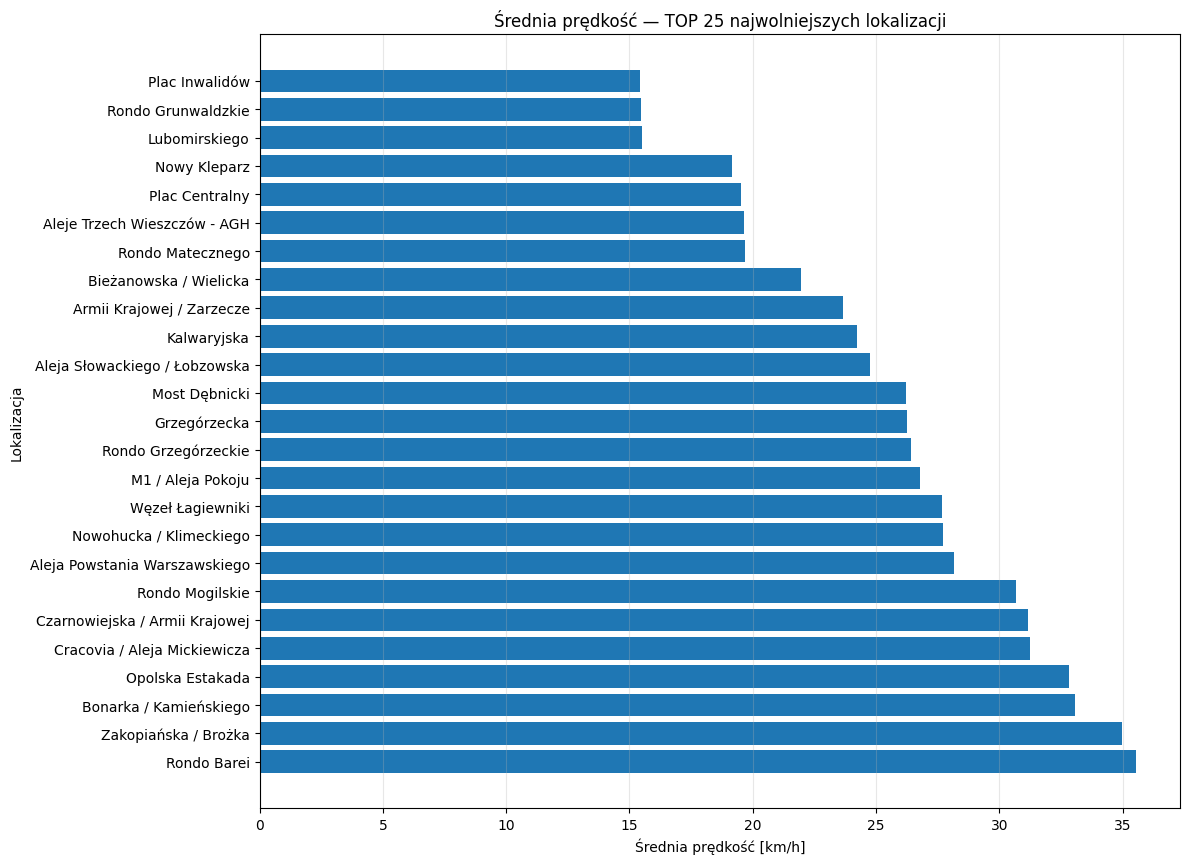

In [6]:
plot_average_speed_by_point(top_n=25)

Top 10 najbardziej zakorkowanych punktów

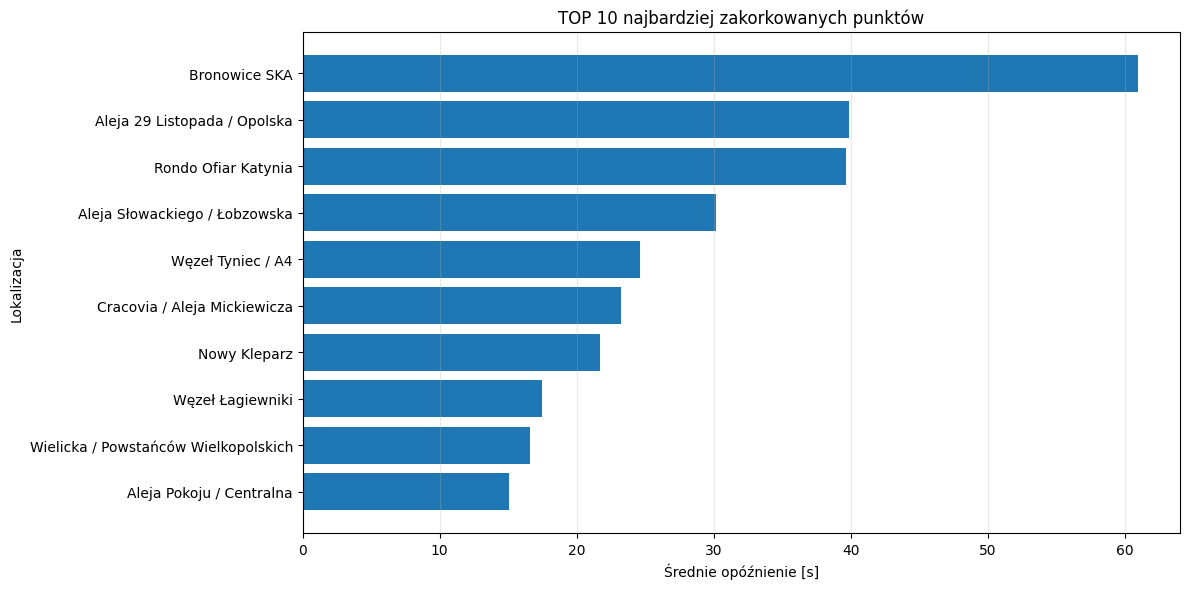

In [7]:
plot_current_congestion_ranking(top_n=10)

Opóżnienia w zaleźności od dnia

/tmp/ipykernel_6676/1351539525.py:891: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



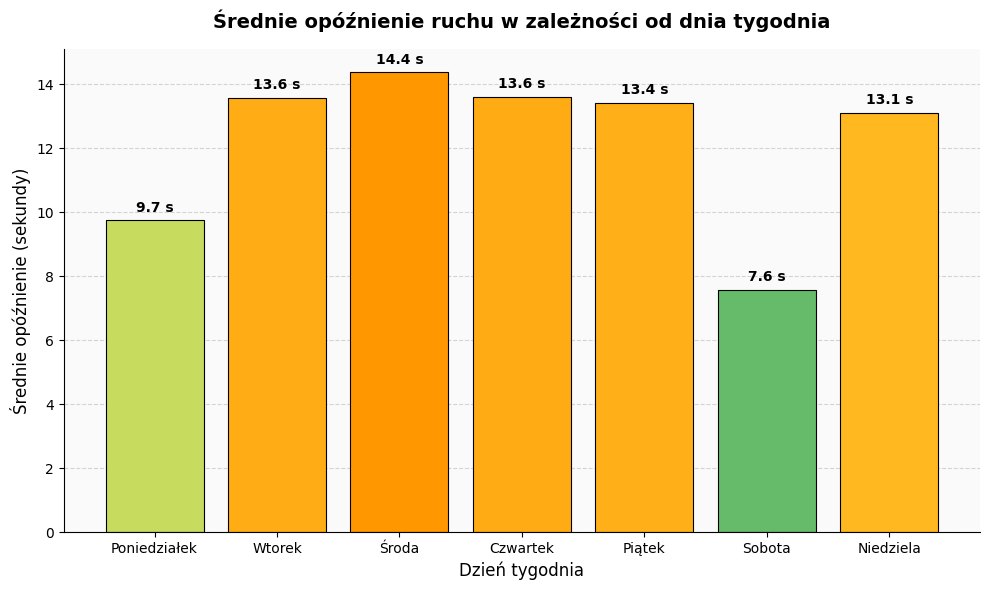

In [33]:
df = pd.read_csv('traffic_history.csv')

plot_delay_by_day(df)

Heatmapa opóznień

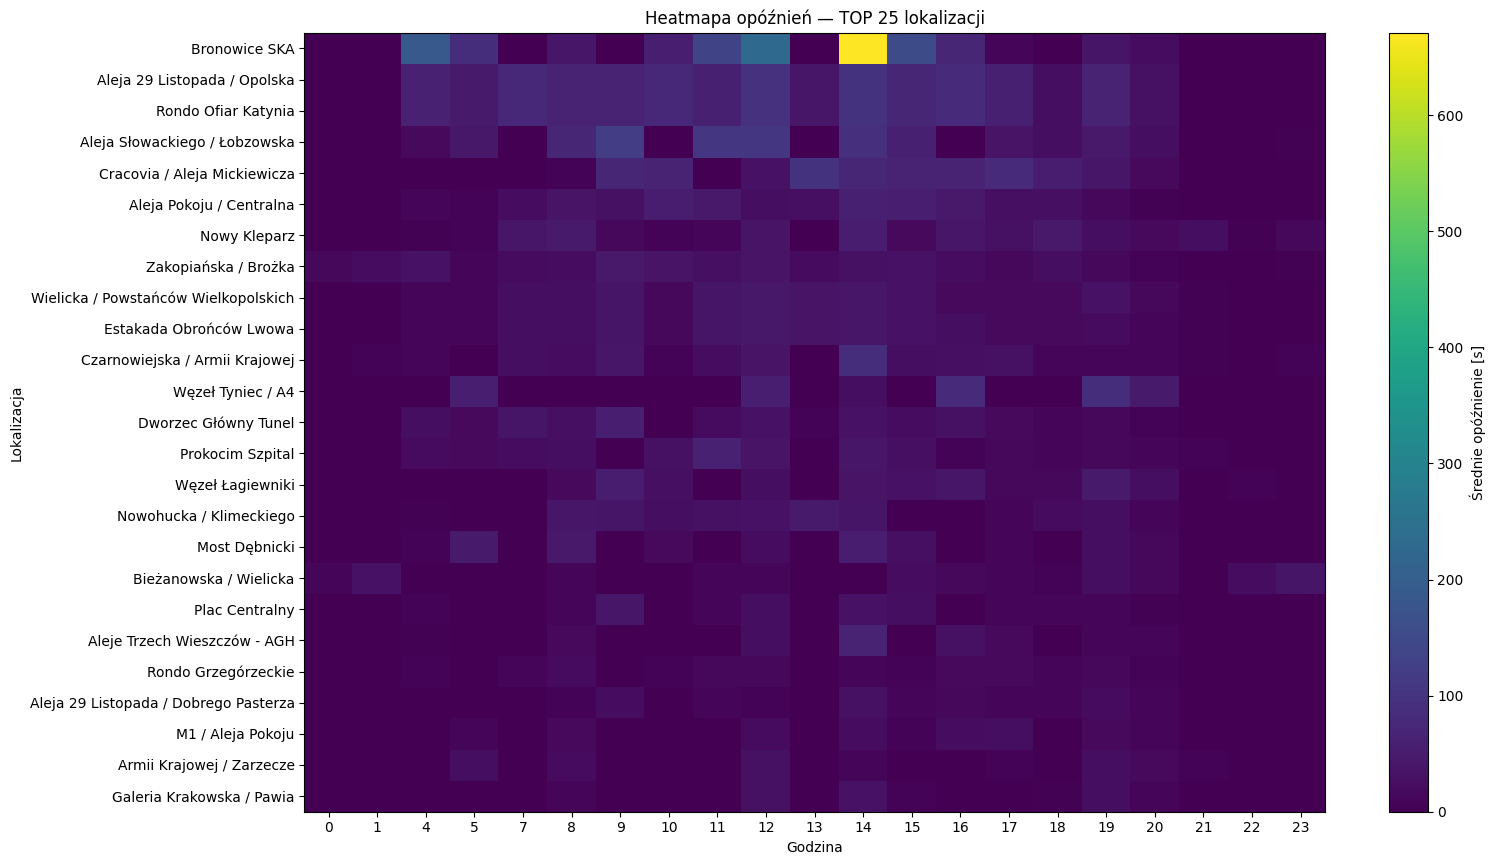

In [8]:
plot_delay_heatmap(top_n=25)


Średnie opóznienie według godziny





In [9]:
plot_interactive_delay_by_hour(top_n=8)

Wyniki najbardziej zakorkowanych punktów dla najnowszego pomiaru

In [12]:
plot_interactive_congestion_ranking(top_n=15)

Pokazanie zakorkowanych węzłów na mapie

In [13]:
plot_interactive_map()

In [14]:
!pip install osmnx
import osmnx as ox
import folium
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import numpy as np

def plot_interactive_street_network_map():
    """Rysuje rozbudowaną mapę Krakowa z opóźnieniami rozproszonymi na siatkę ulic wokół punktów pomiarowych"""

    print("Wczytywanie danych historycznych...")

    try:
        df = load_history()
    except NameError:

        if os.path.exists("traffic_history.csv"):
            df = pd.read_csv("traffic_history.csv")
            df["timestamp"] = pd.to_datetime(df["timestamp"])
        else:
            print("Nie znaleziono pliku traffic_history.csv. Wgraj dane lub uruchom zbieranie.")
            return

    latest_time = df["timestamp"].max()
    df_latest = df[df["timestamp"] == latest_time].copy()
    df_latest['delay_min'] = df_latest['delay_sec'] / 60.0

    lokalizacja = "Kraków, Poland"
    print(f"Pobieranie głównej sieci drogowej Krakowa... (To zajmie chwilę)")

    try:

        G = ox.graph_from_place(lokalizacja, network_type="drive", simplify=True)
    except:
        G = ox.graph_from_place(lokalizacja, network_type="drive")

    print("Generowanie siatki ulic z danymi o ruchu...")

    folium_map = folium.Map(location=[50.0614, 19.9383], zoom_start=12, tiles="cartodbdark_matter")

    # Skala kolorów
    cmap = plt.get_cmap('YlOrRd')
    max_val = df_latest['delay_min'].quantile(0.9) if not df_latest.empty else 10
    norm = mcolors.Normalize(vmin=0, vmax=max(5, max_val))

    for _, row in df_latest.iterrows():
        lat, lon = row['lat'], row['lon']
        delay = row['delay_min']
        p_name = row['point_name']

        try:
            near_edges = ox.features_from_point((lat, lon), tags={"highway": ["primary", "secondary", "tertiary", "trunk", "motorway"]}, dist=600)

            color = mcolors.to_hex(cmap(norm(delay)))
            # Dynamika grubości linii
            weight = 4 + (norm(delay) * 8)

            popup_text = f"<b>{p_name}</b><br>Opóźnienie: {row['delay_sec']}s ({delay:.1f} min)<br>Prędkość: {row['current_speed_kmph']} km/h"

            for _, edge in near_edges.iterrows():
                if hasattr(edge, 'geometry') and edge.geometry:
                    if edge.geometry.geom_type == 'LineString':
                        locations = [(p[1], p[0]) for p in edge.geometry.coords]
                        folium.PolyLine(locations=locations, color=color, weight=weight, opacity=0.85, popup=popup_text).add_to(folium_map)
                    elif edge.geometry.geom_type == 'MultiLineString':
                        for line in edge.geometry.geoms:
                            locations = [(p[1], p[0]) for p in line.coords]
                            folium.PolyLine(locations=locations, color=color, weight=weight, opacity=0.85, popup=popup_text).add_to(folium_map)
        except:
            continue

    print(f"Mapa gotowa. Wykorzystano dane z {len(df_latest)} punktów pomiarowych.")
    print(f"Czas danych: {latest_time}")
    display(folium_map)

plot_interactive_street_network_map()

Wczytywanie danych historycznych...
Pobieranie głównej sieci drogowej Krakowa... (To zajmie chwilę)
Generowanie siatki ulic z danymi o ruchu...
Mapa gotowa. Wykorzystano dane z 41 punktów pomiarowych.
Czas danych: 2026-05-29 08:27:07.248791
